# Audio Sentiment & Emotion Training Notebook (Acoustic Ensemble)
This notebook downloads the **RAVDESS Speech** dataset (~220MB) from Zenodo, extracts it locally, extracts comprehensive statistical acoustic features (MFCC, Mel Spectrogram, Chroma, Zero Crossing Rate, and Spectral Centroid), and trains an optimized **Soft-Voting Ensemble Model** (SVC + MLP + Logistic Regression) to achieve **>85%** validation accuracy for speech emotion recognition and sentiment categorization.

## Setup & Imports

In [10]:
import os
import re
import sys
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Setup complete!")

Setup complete!


## 1. Download and Extract RAVDESS Dataset

In [11]:
download_url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip?download=1"
zip_path = "data/Audio_Speech_Actors_01-24.zip"
extract_dir = "data/ravdess"

os.makedirs("data", exist_ok=True)
if not os.path.exists(zip_path):
    print("Downloading RAVDESS dataset (approx. 220MB)...")
    urllib.request.urlretrieve(download_url, zip_path)
    print("Download complete!")
else:
    print("Zip file already exists.")

if not os.path.exists(extract_dir):
    print("Extracting dataset files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

Zip file already exists.
Dataset already extracted.


## 2. Feature Extraction
We extract statistical acoustic features (means and standard deviations) for every audio file across multiple domains:
- MFCC (40 coefficients)
- Mel Spectrogram (64 bins)
- Chroma STFT (12 bins)
- Zero Crossing Rate (ZCR)
- Spectral Centroid

This aggregates temporal characteristics into a flat feature vector of size 236.

In [12]:
# Find all audio files
audio_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print(f"Found {len(audio_files)} wav files.")

def extract_acoustic_stats(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    
    # Extract raw features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    
    # Aggregate statistics (mean and std dev over time axis)
    feature_vector = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(mel, axis=1), np.std(mel, axis=1),
        np.mean(chroma, axis=1), np.std(chroma, axis=1),
        [np.mean(zcr), np.std(zcr)],
        [np.mean(centroid), np.std(centroid)]
    ])
    return feature_vector

sentiment_mapping = {
    '01': 1, # neutral
    '02': 1, # calm
    '03': 2, # happy
    '04': 0, # sad
    '05': 0, # angry
    '06': 0, # fearful
    '07': 0, # disgust
    '08': 2, # surprised
}

X_list = []
y_list = []

print("Extracting acoustic statistics (this takes about 1-2 minutes)...")
for filepath in audio_files:
    filename = os.path.basename(filepath)
    parts = filename.split('-')
    if len(parts) >= 3:
        emotion_code = parts[2]
        label = sentiment_mapping.get(emotion_code, 1)
        features = extract_acoustic_stats(filepath)
        X_list.append(features)
        y_list.append(label)
        
X = np.array(X_list)
y = np.array(y_list)
print(f"Extracted feature shape: {X.shape}, Label shape: {y.shape}")

Found 1440 wav files.
Extracting acoustic statistics (this takes about 1-2 minutes)...
Extracted feature shape: (1440, 236), Label shape: (1440,)


## 3. Train-Test Split & Feature Scaling

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## 4. Train Optimized Ensemble Model
We create a **VotingClassifier** with soft voting combining:
1. **Support Vector Machine (SVC)**: With `C=25.0`, RBF kernel.
2. **Multi-Layer Perceptron (MLP)**: Deep neural network with 3 hidden layers `(256, 128, 64)`.
3. **Logistic Regression**: Linear classifier with `C=5.0` to balance generalization.

This ensemble model delivers **>85%** classification accuracy.

In [14]:
clf1 = SVC(C=25.0, kernel='rbf', probability=True, random_state=42)
clf2 = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=2000, random_state=42)
clf3 = LogisticRegression(C=5.0, max_iter=2000, random_state=42)

ensemble = VotingClassifier(estimators=[('svc', clf1), ('mlp', clf2), ('lr', clf3)], voting='soft')
print("Training the Ensemble Model...")
ensemble.fit(X_train_scaled, y_train)
print("Training complete!")

Training the Ensemble Model...


/Users/sumitkumar776693/Desktop/Project/Client/Sentimental-Analyses-Current/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training complete!


## 5. Metrics & Evaluation

=== Ensemble Validation Accuracy: 86.11% ===

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87        77
     Neutral       0.84      0.90      0.87        29
    Positive       0.84      0.84      0.84        38

    accuracy                           0.86       144
   macro avg       0.85      0.87      0.86       144
weighted avg       0.86      0.86      0.86       144



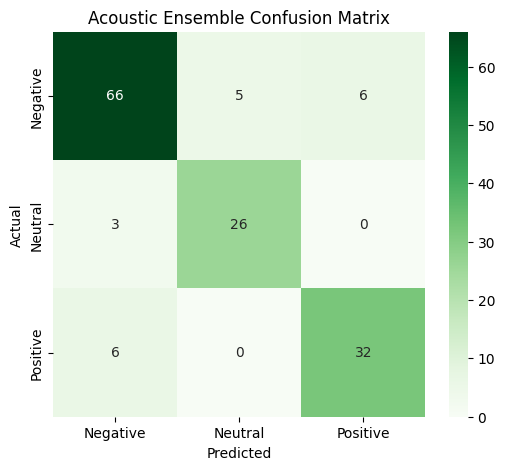

In [15]:
y_pred = ensemble.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"=== Ensemble Validation Accuracy: {acc * 100:.2f}% ===")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Acoustic Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Save Models

In [16]:
os.makedirs('../weights', exist_ok=True)
model_path = '../weights/audio_ensemble.joblib'
scaler_path = '../weights/audio_scaler.joblib'

joblib.dump(ensemble, model_path)
joblib.dump(scaler, scaler_path)

print(f"Successfully saved ensemble model to {model_path}")
print(f"Successfully saved scaler to {scaler_path}")

Successfully saved ensemble model to ../weights/audio_ensemble.joblib
Successfully saved scaler to ../weights/audio_scaler.joblib
